<a href="https://colab.research.google.com/github/aonoa68/GISA2025_mantel_analysis/blob/main/grass_tatara_evolutionary_extensions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Grass–Tatara Evolutionary Anthropology Extensions

このNotebookは、既存の grass–tatara 分析に対して、**進化人類学・文化進化・ニッチ構築**の観点から追加分析を行うための拡張版です。

## 含めた追加分析
1. DEM から `slope` / `curvature` を生成
2. 市町村単位で terrain 指標を集計
3. terrain を含む草地分布モデル
4. `tatara × slope` / `tatara × geology` の交互作用
5. DBSCAN による tatara 点群クラスタリング
6. クラスタ単位の環境要約
7. 1950 / 1965 / 1975 の時系列比較の雛形
8. historical population / density の追加雛形
9. terrain / population を含む分類分析
10. 進化人類学的な最終統合モデル

## 理論的背景
このNotebookの追加部分は、次の問いを意識しています。

- 環境が文化活動を制約するのか
- 文化活動が景観を改変するのか
- その関係は条件依存的か
- cultural clustering は見られるか
- population density と industrial specialization は関係するか

## 前提
- 既存 Notebook の `agg`, `gdf_muni`, `gdf_sites`, `EXTRACT_DIR`, `DEM_PATH` と互換的
- Google Drive 上に各種データがある前提


In [ ]:
# 必要なら最初に実行
# !pip -q install geopandas rasterio rasterstats scipy scikit-learn statsmodels


In [45]:
import os
import warnings
from math import log

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf

import rasterio
from rasterstats import zonal_stats
from scipy.ndimage import gaussian_filter
from scipy.spatial import cKDTree

from sklearn.cluster import DBSCAN
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, make_scorer

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", 300)
pd.set_option("display.max_rows", 200)


In [46]:
from google.colab import drive
drive.mount('/content/drive')

EXTRACT_DIR = "/content/drive/MyDrive/鳥大地理情報研卒論2025/B22A5163M_BITO"

CSV_PATH = os.path.join(
    EXTRACT_DIR,
    "02_世界農業センサス_公私有牧野統計表CSV",
    "鳥取県",
    "世界農業センサス",
    "1950",
    "世界農業センサス＋たたら",
    "tottori20251216.csv"
)

FGB_PATH = os.path.join(
    EXTRACT_DIR,
    "06_混合効果モデル",
    "「流域」「地質」に基づくグループ分け",
    "鳥取県",
    "結果",
    "3guru-pu",
    "「流域」「地質」",
    "basin_geology_group",
    "admin_grass_tatara_basin_geology.fgb"
)

TATARA_POINT_CSV = os.path.join(
    EXTRACT_DIR,
    "04_たたら遺構位置情報CSV",
    "鳥取県",
    "tottoritataraitizyouhou20251228.csv"
)

DEM_PATH = "/content/drive/MyDrive/鳥大地理情報研卒論2025/add_analysis/tottori_Z13DEM_6673.tif"

print("CSV:", os.path.exists(CSV_PATH))
print("FGB:", os.path.exists(FGB_PATH))
print("Tatara CSV:", os.path.exists(TATARA_POINT_CSV))
print("DEM:", os.path.exists(DEM_PATH))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CSV: True
FGB: True
Tatara CSV: True
DEM: True


In [47]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [48]:
def read_csv_multi_encoding(path, encodings=("utf-8-sig", "utf-8", "cp932", "shift_jis")):
    last_error = None
    for enc in encodings:
        try:
            df = pd.read_csv(path, encoding=enc)
            print("CSV encoding:", enc)
            return df
        except Exception as e:
            last_error = e
    raise last_error

def pick_first_existing(columns, candidates):
    for c in candidates:
        if c in columns:
            return c
    return None

def canonicalize_main_df(df_raw):
    muni_col = pick_first_existing(df_raw.columns, [
        "municipality", "N03_004", "市町村名", "世界農業センサス1950 - 1950年csv用整形データ_結合用都市町村"
    ])
    grass_col = pick_first_existing(df_raw.columns, [
        "grass", "世界農業センサス1950 - 1950年csv用整形データ_採草地・放牧地・貸付地面積"
    ])
    count_col = pick_first_existing(df_raw.columns, ["count", "No_count"])
    assert muni_col and grass_col and count_col, "主要列が見つかりません"

    out = df_raw.copy().rename(columns={
        muni_col: "municipality",
        grass_col: "grass",
        count_col: "count"
    })
    out["grass"] = pd.to_numeric(out["grass"], errors="coerce")
    out["count"] = pd.to_numeric(out["count"], errors="coerce")
    return out.dropna(subset=["municipality", "grass", "count"]).copy()

def canonicalize_geo_gdf(gdf_raw):
    muni_col = pick_first_existing(gdf_raw.columns, [
        "municipality", "N03_004", "市町村名", "世界農業センサス1950 - 1950年csv用整形データ_結合用都市町村"
    ])
    basin_col = pick_first_existing(gdf_raw.columns, ["basin", "W07_004"])
    geology_col = pick_first_existing(gdf_raw.columns, ["geology", "legend_group_ja", "legend_lithology_ja"])
    rename_map = {}
    if muni_col: rename_map[muni_col] = "municipality"
    if basin_col: rename_map[basin_col] = "basin"
    if geology_col: rename_map[geology_col] = "geology"
    gdf = gdf_raw.copy().rename(columns=rename_map)
    keep = [c for c in ["municipality", "basin", "geology", "geometry"] if c in gdf.columns]
    return gdf[keep].dropna(subset=["municipality", "geometry"]).copy()

def safe_area(gdf):
    try:
        return gdf.to_crs(6677).geometry.area
    except Exception:
        try:
            return gdf.to_crs(3857).geometry.area
        except Exception:
            return pd.Series(np.nan, index=gdf.index)

def entropy_from_shares(shares):
    shares = [s for s in shares if s > 0]
    if len(shares) <= 1:
        return 0.0
    H = -sum(s * log(s) for s in shares)
    Hmax = log(len(shares))
    return H / Hmax if Hmax > 0 else 0.0

def rock_family(label):
    if pd.isna(label):
        return "unknown"
    s = str(label)
    if any(k in s for k in ["火成", "花崗", "安山岩", "玄武岩", "流紋岩", "閃緑"]):
        return "igneous"
    if any(k in s for k in ["堆積", "砂岩", "泥岩", "頁岩", "石灰岩", "礫岩"]):
        return "sedimentary"
    if any(k in s for k in ["変成", "片岩", "片麻岩", "結晶片岩", "ホルンフェルス"]):
        return "metamorphic"
    return "other"

def canonicalize_tatara_point_csv(df_raw):
    lon_col = pick_first_existing(df_raw.columns, ["経度", "lon", "longitude", "x"])
    lat_col = pick_first_existing(df_raw.columns, ["緯度", "lat", "latitude", "y"])
    assert lon_col and lat_col, "経度・緯度列が見つかりません"

    out = df_raw.copy().rename(columns={lon_col: "lon", lat_col: "lat"})
    out["lon"] = pd.to_numeric(out["lon"], errors="coerce")
    out["lat"] = pd.to_numeric(out["lat"], errors="coerce")
    out = out.dropna(subset=["lon", "lat"]).copy()
    return gpd.GeoDataFrame(out, geometry=gpd.points_from_xy(out["lon"], out["lat"]), crs="EPSG:4326")


## 1. 基礎データの再構成

既存 Notebook の `agg`, `gdf_muni`, `gdf_sites` 相当のデータをここで作ります。

In [49]:
df = canonicalize_main_df(read_csv_multi_encoding(CSV_PATH))
gdf = canonicalize_geo_gdf(gpd.read_file(FGB_PATH))
gdf["poly_area"] = safe_area(gdf).fillna(0)

# municipality polygons
gdf_muni = gdf[["municipality", "geometry"]].dissolve(by="municipality").reset_index()
if gdf_muni.crs is None:
    gdf_muni = gdf_muni.set_crs(gdf.crs)
gdf_muni = gdf_muni.to_crs(6677)

# basin main
if "basin" in gdf.columns:
    basin_area = gdf.groupby(["municipality", "basin"], dropna=False)["poly_area"].sum().reset_index()
    basin_main = basin_area.sort_values(["municipality", "poly_area"], ascending=[True, False]).drop_duplicates("municipality")
    basin_main = basin_main.rename(columns={"basin": "basin_main"})
else:
    basin_main = pd.DataFrame({"municipality": gdf["municipality"].unique(), "basin_main": "NA"})

# geology summary
if "geology" in gdf.columns:
    geo_area = gdf.groupby(["municipality", "geology"], dropna=False)["poly_area"].sum().reset_index()
    total_geo = geo_area.groupby("municipality")["poly_area"].sum().rename("total_geo_area").reset_index()
    geo_area = geo_area.merge(total_geo, on="municipality", how="left")
    geo_area["share"] = np.where(geo_area["total_geo_area"] > 0, geo_area["poly_area"] / geo_area["total_geo_area"], np.nan)
    geo_area["rock_family"] = geo_area["geology"].map(rock_family)

    entropy_tbl = geo_area.groupby("municipality")["share"].apply(
        lambda s: entropy_from_shares(s.dropna().tolist())
    ).rename("geology_entropy").reset_index()

    fam_tbl = geo_area.groupby(["municipality", "rock_family"])["share"].sum().reset_index().pivot(
        index="municipality", columns="rock_family", values="share"
    ).fillna(0).reset_index()

    for col in ["igneous", "sedimentary", "metamorphic", "other", "unknown"]:
        if col not in fam_tbl.columns:
            fam_tbl[col] = 0.0

    fam_tbl = fam_tbl.rename(columns={
        "igneous": "igneous_share",
        "sedimentary": "sedimentary_share",
        "metamorphic": "metamorphic_share",
        "other": "other_rock_share",
        "unknown": "unknown_rock_share",
    })
else:
    entropy_tbl = pd.DataFrame({"municipality": gdf["municipality"].unique(), "geology_entropy": np.nan})
    fam_tbl = pd.DataFrame({"municipality": gdf["municipality"].unique()})

# basin entropy
if "basin" in gdf.columns:
    basin_area2 = gdf.groupby(["municipality", "basin"], dropna=False)["poly_area"].sum().reset_index()
    total_basin = basin_area2.groupby("municipality")["poly_area"].sum().rename("total_basin_area").reset_index()
    basin_area2 = basin_area2.merge(total_basin, on="municipality", how="left")
    basin_area2["share"] = np.where(basin_area2["total_basin_area"] > 0, basin_area2["poly_area"] / basin_area2["total_basin_area"], np.nan)
    basin_entropy_tbl = basin_area2.groupby("municipality")["share"].apply(
        lambda s: entropy_from_shares(s.dropna().tolist())
    ).rename("basin_entropy").reset_index()
else:
    basin_entropy_tbl = pd.DataFrame({"municipality": gdf["municipality"].unique(), "basin_entropy": np.nan})

# merge
agg = (
    df.merge(basin_main[["municipality", "basin_main"]], on="municipality", how="left")
      .merge(entropy_tbl, on="municipality", how="left")
      .merge(fam_tbl, on="municipality", how="left")
      .merge(basin_entropy_tbl, on="municipality", how="left")
)

for c in ["geology_entropy", "basin_entropy", "igneous_share", "sedimentary_share", "metamorphic_share",
          "other_rock_share", "unknown_rock_share"]:
    if c in agg.columns:
        agg[c] = agg[c].fillna(0)

# geology main group
if "geology" in gdf.columns:
    geo_area_main = gdf.groupby(["municipality", "geology"], dropna=False)["poly_area"].sum().reset_index()
    geo_main = geo_area_main.sort_values(["municipality", "poly_area"], ascending=[True, False]).drop_duplicates("municipality")
    geo_main = geo_main.rename(columns={"geology": "geology_main"})
    agg = agg.merge(geo_main[["municipality", "geology_main"]], on="municipality", how="left")
    vc = agg["geology_main"].astype(str).value_counts()
    top_levels = set(vc.head(6).index)
    agg["geology_main_grp"] = agg["geology_main"].astype(str).where(
        agg["geology_main"].astype(str).isin(top_levels), "Other"
    )
else:
    agg["geology_main_grp"] = "NA"

# sites
gdf_sites = canonicalize_tatara_point_csv(read_csv_multi_encoding(TATARA_POINT_CSV)).to_crs(6677)

display(agg.head())
print("agg shape:", agg.shape)
print("gdf_sites shape:", gdf_sites.shape)


CSV encoding: utf-8-sig
CSV encoding: utf-8-sig


,fid,N03_001,N03_002,N03_003,municipality,N03_005,N03_006,N03_007,世界農業センサス1950 - 1950年csv用整形データ_結合用都市町村,世界農業センサス1950 - 1950年csv用整形データ_地域,世界農業センサス1950 - 1950年csv用整形データ_総数,世界農業センサス1950 - 1950年csv用整形データ_牧草畑面積,世界農業センサス1950 - 1950年csv用整形データ_採草地面積,世界農業センサス1950 - 1950年csv用整形データ_放牧地面積,世界農業センサス1950 - 1950年csv用整形データ_採草地・放牧地・貸付地面積,世界農業センサス1950 - 1950年csv用整形データ_放牧する山林面積,grass,count,遺跡名_count,経度_count,緯度_count,管理番号_count,市町村名_count,ふりがな_count,所在地_count,種類_count,時代_count,遺物_count,遺構_count,遺跡概要_count,文献_count,basin_main,geology_entropy,igneous_share,metamorphic_share,other_rock_share,sedimentary_share,unknown_rock_share,basin_entropy,geology_main,geology_main_grp
0,46,鳥取県,NaN,気高郡,中郷村,NaN,NaN,31000,中郷村,67 中郷村,4.04,NaN,0.97,NaN,3.07,NaN,4,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,勝部川,0.575785,0.863204,0.0,0.0,0.136796,0.0,0.0,火成岩,火成岩
1,52,鳥取県,NaN,東伯郡,八橋町,NaN,NaN,31000,八橋町,107 八橋村,34.69,0.50,18.17,0.21,11.51,4.30,35,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,八橋川,0.722014,0.799957,0.0,0.0,0.200043,0.0,0.0,火成岩,火成岩
2,63,鳥取県,NaN,東伯郡,成美村,NaN,NaN,31000,成美村,109 成美村,57.39,0.02,56.15,0.52,0.62,0.08,57,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,黒川,0.862153,0.715016,0.0,0.0,0.284984,0.0,0.0,火成岩,火成岩
3,67,鳥取県,NaN,東伯郡,上中山村,NaN,NaN,31000,上中山村,112 上中山村,94.08,0.59,44.97,25.19,6.81,16.52,94,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,甲川,0.812567,0.749185,0.0,0.0,0.250815,0.0,0.0,火成岩,火成岩
4,69,鳥取県,NaN,西伯郡,光徳村,NaN,NaN,31000,光徳村,152光徳村,26.61,0.20,11.66,NaN,14.13,0.62,27,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,真子川,0.000000,1.000000,0.0,0.0,0.000000,0.0,0.0,火成岩,火成岩


agg shape: (55, 41)
gdf_sites shape: (562, 15)


## 2. DEM から slope / curvature を生成

In [50]:
SLOPE_TIF = os.path.join(EXTRACT_DIR, "DEM", "tottori_slope.tif")
CURV_TIF  = os.path.join(EXTRACT_DIR, "DEM", "tottori_curvature.tif")

def make_dem_derivatives(dem_path, slope_tif, curv_tif, smooth_sigma=1.0):
    with rasterio.open(dem_path) as src:
        dem = src.read(1, masked=True).astype("float64")
        profile = src.profile.copy()
        transform = src.transform

        dx = transform.a
        dy = abs(transform.e)

        arr = dem.filled(np.nan)
        arr_s = gaussian_filter(np.nan_to_num(arr, nan=np.nanmedian(arr)), sigma=smooth_sigma)

        dz_dy, dz_dx = np.gradient(arr_s, dy, dx)

        slope_rad = np.arctan(np.sqrt(dz_dx**2 + dz_dy**2))
        slope_deg = np.degrees(slope_rad)

        d2z_dx2 = np.gradient(dz_dx, dx, axis=1)
        d2z_dy2 = np.gradient(dz_dy, dy, axis=0)
        curvature = d2z_dx2 + d2z_dy2

        profile.update(dtype="float32", count=1, compress="lzw", nodata=np.nan)

        with rasterio.open(slope_tif, "w", **profile) as dst:
            dst.write(slope_deg.astype("float32"), 1)

        with rasterio.open(curv_tif, "w", **profile) as dst:
            dst.write(curvature.astype("float32"), 1)

    print("saved:", slope_tif)
    print("saved:", curv_tif)

if os.path.exists(DEM_PATH):
    make_dem_derivatives(DEM_PATH, SLOPE_TIF, CURV_TIF)
else:
    print("DEM not found; skip derivative generation.")


saved: /content/drive/MyDrive/鳥大地理情報研卒論2025/B22A5163M_BITO/DEM/tottori_slope.tif
saved: /content/drive/MyDrive/鳥大地理情報研卒論2025/B22A5163M_BITO/DEM/tottori_curvature.tif


## 3. 市町村単位で terrain 指標を集計

In [51]:
for c in ["elev_mean", "elev_sd", "elev_min", "elev_max", "slope_mean", "slope_sd", "slope_max", "curv_mean", "curv_sd"]:
    if c not in agg.columns:
        agg[c] = np.nan

if os.path.exists(DEM_PATH):
    with rasterio.open(DEM_PATH) as src:
        dem_crs = src.crs

    gdf_muni_dem = gdf_muni.to_crs(dem_crs)

    dem_zs = zonal_stats(gdf_muni_dem, DEM_PATH, stats=["mean", "std", "min", "max"], nodata=np.nan)
    slope_zs = zonal_stats(gdf_muni_dem, SLOPE_TIF, stats=["mean", "std", "max"], nodata=np.nan) if os.path.exists(SLOPE_TIF) else None
    curv_zs  = zonal_stats(gdf_muni_dem, CURV_TIF,  stats=["mean", "std"], nodata=np.nan) if os.path.exists(CURV_TIF) else None

    dem_df = pd.DataFrame(dem_zs).rename(columns={"mean":"elev_mean","std":"elev_sd","min":"elev_min","max":"elev_max"})
    slope_df = pd.DataFrame(slope_zs).rename(columns={"mean":"slope_mean","std":"slope_sd","max":"slope_max"}) if slope_zs is not None else pd.DataFrame()
    curv_df  = pd.DataFrame(curv_zs).rename(columns={"mean":"curv_mean","std":"curv_sd"}) if curv_zs is not None else pd.DataFrame()

    terrain_df = pd.concat(
        [gdf_muni[["municipality"]].reset_index(drop=True),
         dem_df.reset_index(drop=True),
         slope_df.reset_index(drop=True),
         curv_df.reset_index(drop=True)],
        axis=1
    )

    agg = agg.drop(columns=["elev_mean", "elev_sd", "elev_min", "elev_max",
                            "slope_mean", "slope_sd", "slope_max", "curv_mean", "curv_sd"], errors="ignore")
    agg = agg.merge(terrain_df, on="municipality", how="left")

display(agg[["municipality", "elev_mean", "slope_mean", "slope_sd", "curv_mean"]].head())


,municipality,elev_mean,slope_mean,slope_sd,curv_mean
0,中郷村,132.111998,17.846244,10.315028,-0.000010
1,八橋町,102.161069,10.333916,9.101853,0.000798
2,成美村,157.746612,14.467608,11.101838,-0.000116
3,上中山村,209.486581,11.566447,9.041782,0.000074
4,光徳村,93.174560,6.310174,5.629621,0.000627


## 4. terrain を含む草地分布モデル

In [52]:
m_terrain_1 = smf.ols(
    '''
    grass ~ geology_entropy
          + igneous_share
          + sedimentary_share
          + metamorphic_share
          + basin_entropy
          + elev_mean
          + elev_sd
          + slope_mean
          + slope_sd
          + curv_mean
    ''',
    data=agg
).fit()

m_terrain_2 = smf.ols(
    '''
    grass ~ geology_entropy
          + igneous_share
          + sedimentary_share
          + metamorphic_share
          + basin_entropy
          + elev_mean
          + elev_sd
          + slope_mean
          + slope_sd
          + curv_mean
          + count
    ''',
    data=agg
).fit()

cmp_terrain = pd.DataFrame({
    "model": ["terrain_base", "terrain_plus_tatara"],
    "AIC": [m_terrain_1.aic, m_terrain_2.aic],
    "R2": [m_terrain_1.rsquared, m_terrain_2.rsquared]
})

display(cmp_terrain)
print(m_terrain_2.summary())


,model,AIC,R2
0,terrain_base,633.908457,0.459071
1,terrain_plus_tatara,634.714452,0.470687


                            OLS Regression Results                            
Dep. Variable:                  grass   R-squared:                       0.471
Model:                            OLS   Adj. R-squared:                  0.335
Method:                 Least Squares   F-statistic:                     3.476
Date:                Sat, 14 Mar 2026   Prob (F-statistic):            0.00158
Time:                        23:13:18   Log-Likelihood:                -305.36
No. Observations:                  55   AIC:                             634.7
Df Residuals:                      43   BIC:                             658.8
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept          -962.2959    812.41

## 5. `tatara × slope` / `tatara × geology` の交互作用

進化人類学的には、これが **文化適応の条件依存性** を見る重要な分析です。

In [53]:
m_inter_slope = smf.ols(
    '''
    grass ~ geology_entropy
          + basin_entropy
          + elev_mean
          + slope_mean
          + curv_mean
          + count
          + count:slope_mean
    ''',
    data=agg
).fit()

print("=== tatara x slope ===")
print(m_inter_slope.summary())

m_inter_geo = smf.ols(
    '''
    grass ~ geology_entropy
          + basin_entropy
          + elev_mean
          + slope_mean
          + curv_mean
          + count
          + count:geology_entropy
    ''',
    data=agg
).fit()

print("=== tatara x geology_entropy ===")
print(m_inter_geo.summary())


=== tatara x slope ===
                            OLS Regression Results                            
Dep. Variable:                  grass   R-squared:                       0.485
Model:                            OLS   Adj. R-squared:                  0.408
Method:                 Least Squares   F-statistic:                     6.311
Date:                Sat, 14 Mar 2026   Prob (F-statistic):           3.03e-05
Time:                        23:13:25   Log-Likelihood:                -304.63
No. Observations:                  55   AIC:                             625.3
Df Residuals:                      47   BIC:                             641.3
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept        

## 6. DBSCAN による tatara 点群クラスタリング

これは **cultural clustering** を調べる分析です。  
`eps` と `min_samples` は要調整です。

cluster_id
-1     24
 0    206
 1      9
 2      9
 3    314
Name: count, dtype: int64


,cluster_id,n_sites,mean_x,mean_y
3,3,314,-588916.613568,-65726.440441
0,0,206,-545972.256531,-54611.365797
1,1,9,-565687.034505,-39647.737183
2,2,9,-572246.235556,-39004.385183


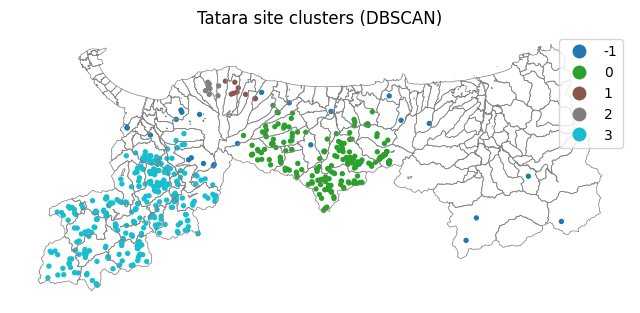

In [54]:
pts = gdf_sites.to_crs(6677).copy()
coords = np.array([(geom.x, geom.y) for geom in pts.geometry])

db = DBSCAN(eps=3000, min_samples=5)
labels = db.fit_predict(coords)
pts["cluster_id"] = labels

print(pts["cluster_id"].value_counts(dropna=False).sort_index())

cluster_summary = (
    pts[pts["cluster_id"] >= 0]
    .groupby("cluster_id")
    .agg(
        n_sites=("cluster_id", "size"),
        mean_x=("geometry", lambda s: np.mean([g.x for g in s])),
        mean_y=("geometry", lambda s: np.mean([g.y for g in s])),
    )
    .reset_index()
    .sort_values("n_sites", ascending=False)
)

display(cluster_summary)

fig, ax = plt.subplots(figsize=(8, 8))
gdf_muni.boundary.plot(ax=ax, color="gray", linewidth=0.5)
pts.plot(column="cluster_id", ax=ax, categorical=True, legend=True, markersize=8)
ax.set_title("Tatara site clusters (DBSCAN)")
ax.axis("off")
plt.show()


## 7. クラスタ単位の環境要約

In [55]:
cluster_hulls = (
    pts[pts["cluster_id"] >= 0]
    .dissolve(by="cluster_id")
    .convex_hull
)

cluster_gdf = gpd.GeoDataFrame(
    {"cluster_id": cluster_hulls.index},
    geometry=cluster_hulls.values,
    crs=pts.crs
)

muni_env = gdf_muni.merge(
    agg[["municipality", "grass", "count", "basin_main", "geology_main_grp", "elev_mean", "slope_mean", "curv_mean"]],
    on="municipality",
    how="left"
)

cluster_env = gpd.overlay(cluster_gdf, muni_env, how="intersection")

cluster_env_summary = (
    cluster_env.groupby("cluster_id")
    .agg(
        n_muni=("municipality", "nunique"),
        grass_mean=("grass", "mean"),
        tatara_mean=("count", "mean"),
        elev_mean=("elev_mean", "mean"),
        slope_mean=("slope_mean", "mean"),
        curv_mean=("curv_mean", "mean"),
    )
    .reset_index()
)

display(cluster_env_summary)


,cluster_id,n_muni,grass_mean,tatara_mean,elev_mean,slope_mean,curv_mean
0,0,25,50.888889,11.666667,291.966908,17.874927,-0.000003
1,1,7,50.000000,3.000000,197.741561,12.638163,0.000254
2,2,3,28.000000,3.333333,195.251848,10.032716,0.000275
3,3,23,121.772727,14.545455,434.648350,19.001146,-0.000008


## 8. 1950 / 1965 / 1975 の時系列比較（雛形）

ファイルパスを埋めればそのまま動く形にしてあります。

/content/drive/MyDrive/鳥大地理情報研卒論2025/B22A5163M_BITO/02_世界農業センサス_公私有牧野統計表CSV/鳥取県/世界農業センサス/1950/世界農業センサス1950 - 1950年csv用整形データ/世界農業センサス1950 - 1950年csv用整形データ.csv => True
/content/drive/MyDrive/鳥大地理情報研卒論2025/B22A5163M_BITO/02_世界農業センサス_公私有牧野統計表CSV/鳥取県/世界農業センサス/1960/世界農業センサス1960 - 1960年csv用整形データ/世界農業センサス1960 - 1960年csv用整形データ全地域版.csv => True
/content/drive/MyDrive/鳥大地理情報研卒論2025/B22A5163M_BITO/02_世界農業センサス_公私有牧野統計表CSV/鳥取県/世界農業センサス/1975/世界農業センサス1975　 - 1975年csv用整形データ/世界農業センサス1975　 - 1975年csv用整形データ.csv => True
Loaded 世界農業センサス1950 - 1950年csv用整形データ.csv with encoding=utf-8-sig
Loaded 世界農業センサス1960 - 1960年csv用整形データ全地域版.csv with encoding=utf-8-sig
Loaded 世界農業センサス1975　 - 1975年csv用整形データ.csv with encoding=utf-8-sig
1950: (175, 4)
1960: (195, 4)
1975: (33, 4)


,municipality,region,grass_area,year
1,鳥取市,1 鳥取市,13.33,1950
2,米子市,2 米子市,27.58,1950
3,岩美郡,岩美郡,33.09,1950
4,米里村,3 米里村,0.72,1950
5,倉田村,4 倉田村,1.07,1950


,municipality,region,grass_area,year
3,鳥取市,鳥取市,159.0,1960
4,鳥取市,鳥取市,17.0,1960
5,米里村,米里村,0.0,1960
6,倉田村,倉田村,1.0,1960
7,面影村,面影村,2.0,1960


,municipality,region,grass_area,year
1,鳥取市,鳥取市,6.0,1975
2,米子市,米子市,10.0,1975
3,倉吉市,倉吉市,17.0,1975
4,境港市,境港市,0.0,1975
7,岩美町,岩美町,1.0,1975


panel shape: (403, 18)


,municipality,region,grass_area,year,count,basin_main,basin_entropy,geology_main_grp,geology_entropy,igneous_share,sedimentary_share,metamorphic_share,elev_mean,elev_sd,slope_mean,slope_sd,curv_mean,curv_sd
0,鳥取市,1 鳥取市,13.33,1950,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,米子市,2 米子市,27.58,1950,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,岩美郡,岩美郡,33.09,1950,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,米里村,3 米里村,0.72,1950,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,倉田村,4 倉田村,1.07,1950,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,year,grass_mean,grass_median,grass_sum,n_muni
0,1950,8.033657,2.72,1405.89,170
1,1960,307.676923,32.00,59997.00,183
2,1975,5.606061,2.00,185.00,33


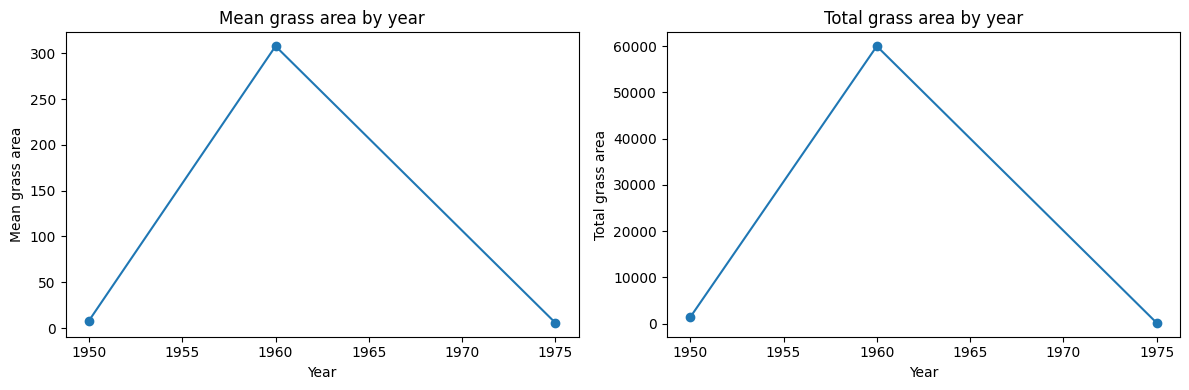

                            OLS Regression Results                            
Dep. Variable:             grass_area   R-squared:                       0.404
Model:                            OLS   Adj. R-squared:                  0.367
Method:                 Least Squares   F-statistic:                     10.84
Date:                Sat, 14 Mar 2026   Prob (F-statistic):           2.22e-10
Time:                        23:55:20   Log-Likelihood:                -869.01
No. Observations:                 120   AIC:                             1754.
Df Residuals:                     112   BIC:                             1776.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          47.0096    164.020     

,municipality,grass_1950,grass_1960,grass_1975,delta_50_75,delta_50_60,delta_60_75,count,basin_main,basin_entropy,geology_main_grp,geology_entropy,igneous_share,sedimentary_share,metamorphic_share,elev_mean,elev_sd,slope_mean,slope_sd,curv_mean,curv_sd
0,三徳村,1.41,187.0,NaN,NaN,185.59,NaN,4.0,天神川,0.0,火成岩,0.261488,0.955741,0.044259,0.0,433.550469,183.805175,24.815663,10.588561,-0.000018,0.011950
1,三朝村,0.95,22.0,NaN,NaN,21.05,NaN,2.0,天神川,0.0,火成岩,0.726820,0.797541,0.202459,0.0,155.769236,90.885545,18.106163,10.684135,-0.000024,0.011060
2,三朝町,NaN,1009.0,1.0,NaN,NaN,-1008.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,三谷村,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,上中山村,6.81,656.0,NaN,NaN,649.19,NaN,5.0,甲川,0.0,火成岩,0.812567,0.749185,0.250815,0.0,209.486581,103.717296,11.566447,9.041782,0.000074,0.008205


                            OLS Regression Results                            
Dep. Variable:            delta_50_75   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                    nan
Method:                 Least Squares   F-statistic:                       nan
Date:                Sat, 14 Mar 2026   Prob (F-statistic):                nan
Time:                        23:55:20   Log-Likelihood:                 105.68
No. Observations:                   4   AIC:                            -203.4
Df Residuals:                       0   BIC:                            -205.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         -12.0093        inf     

In [65]:
import os
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# ----------------------------
# 1. アップロード済みCSVのパス
# ----------------------------
CSV_1950 = "/content/drive/MyDrive/鳥大地理情報研卒論2025/B22A5163M_BITO/02_世界農業センサス_公私有牧野統計表CSV/鳥取県/世界農業センサス/1950/世界農業センサス1950 - 1950年csv用整形データ/世界農業センサス1950 - 1950年csv用整形データ.csv"
CSV_1960 = "/content/drive/MyDrive/鳥大地理情報研卒論2025/B22A5163M_BITO/02_世界農業センサス_公私有牧野統計表CSV/鳥取県/世界農業センサス/1960/世界農業センサス1960 - 1960年csv用整形データ/世界農業センサス1960 - 1960年csv用整形データ全地域版.csv"
CSV_1975 = "/content/drive/MyDrive/鳥大地理情報研卒論2025/B22A5163M_BITO/02_世界農業センサス_公私有牧野統計表CSV/鳥取県/世界農業センサス/1975/世界農業センサス1975　 - 1975年csv用整形データ/世界農業センサス1975　 - 1975年csv用整形データ.csv"

# 念のため存在確認
for p in [CSV_1950, CSV_1960, CSV_1975]:
    print(p, "=>", os.path.exists(p))


# ----------------------------
# 2. 文字コードを自動で試す関数
# ----------------------------
def read_csv_multi_encoding(path, encodings=("utf-8-sig", "utf-8", "cp932", "shift_jis")):
    last_error = None
    for enc in encodings:
        try:
            df = pd.read_csv(path, encoding=enc)
            print(f"Loaded {os.path.basename(path)} with encoding={enc}")
            return df
        except Exception as e:
            last_error = e
    raise last_error


# ----------------------------
# 3. 年ごとの整形関数
#    grass_area を共通列にそろえる
# ----------------------------
def load_census_1950(path):
    df = read_csv_multi_encoding(path).copy()
    df = df.rename(columns={
        "結合用都市町村": "municipality",
        "地域": "region",
        "採草地・放牧地・貸付地面積": "grass_area"
    })
    keep = ["municipality", "region", "grass_area"]
    df = df[keep].copy()
    df["grass_area"] = pd.to_numeric(df["grass_area"], errors="coerce")
    df["year"] = 1950
    return df.dropna(subset=["municipality", "grass_area"])


def load_census_1960(path):
    df = read_csv_multi_encoding(path).copy()
    df = df.rename(columns={
        "結合用都市町村": "municipality",
        "地域名": "region",
        "採草地": "grass_cut",
        "放牧地": "grass_grazing"
    })
    df["grass_cut"] = pd.to_numeric(df["grass_cut"], errors="coerce")
    df["grass_grazing"] = pd.to_numeric(df["grass_grazing"], errors="coerce")
    df["grass_area"] = df[["grass_cut", "grass_grazing"]].sum(axis=1, min_count=1)
    keep = ["municipality", "region", "grass_area"]
    df = df[keep].copy()
    df["year"] = 1960
    return df.dropna(subset=["municipality", "grass_area"])


def load_census_1975(path):
    df = read_csv_multi_encoding(path).copy()
    df = df.rename(columns={
        "結合用都市町村": "municipality",
        "牧草専用地面積": "grass_area",
        "Unnamed: 1": "region"
    })
    keep = ["municipality", "region", "grass_area"]
    df = df[keep].copy()
    df["grass_area"] = pd.to_numeric(df["grass_area"], errors="coerce")
    df["year"] = 1975
    return df.dropna(subset=["municipality", "grass_area"])


# ----------------------------
# 4. 読み込み
# ----------------------------
df1950 = load_census_1950(CSV_1950)
df1960 = load_census_1960(CSV_1960)
df1975 = load_census_1975(CSV_1975)

print("1950:", df1950.shape)
print("1960:", df1960.shape)
print("1975:", df1975.shape)

display(df1950.head())
display(df1960.head())
display(df1975.head())


# ----------------------------
# 5. パネル化
#    既存の agg から環境変数を引き継ぐ
#    agg は 1950ベースで municipality ごとの
#    geology / basin / DEM / tatara count を持っている前提
# ----------------------------
env_cols = [
    "municipality",
    "count",
    "basin_main",
    "basin_entropy",
    "geology_main_grp",
    "geology_entropy",
    "igneous_share",
    "sedimentary_share",
    "metamorphic_share",
    "elev_mean",
    "elev_sd",
    "slope_mean",
    "slope_sd",
    "curv_mean",
    "curv_sd",
]

env_cols = [c for c in env_cols if c in agg.columns]

panel = pd.concat([df1950, df1960, df1975], axis=0, ignore_index=True)
panel = panel.merge(agg[env_cols].drop_duplicates("municipality"), on="municipality", how="left")

print("panel shape:", panel.shape)
display(panel.head())


# ----------------------------
# 6. 年ごとの要約
# ----------------------------
panel_summary = panel.groupby("year").agg(
    grass_mean=("grass_area", "mean"),
    grass_median=("grass_area", "median"),
    grass_sum=("grass_area", "sum"),
    n_muni=("municipality", "nunique")
).reset_index()

display(panel_summary)

# 可視化
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(panel_summary["year"], panel_summary["grass_mean"], marker="o")
axes[0].set_title("Mean grass area by year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Mean grass area")

axes[1].plot(panel_summary["year"], panel_summary["grass_sum"], marker="o")
axes[1].set_title("Total grass area by year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Total grass area")

plt.tight_layout()
plt.show()


# ----------------------------
# 7. 基本パネル回帰
#    年効果を見る
# ----------------------------
m_panel_1 = smf.ols(
    """
    grass_area ~ C(year)
              + geology_entropy
              + basin_entropy
              + elev_mean
              + slope_mean
              + count
    """,
    data=panel
).fit()

print(m_panel_1.summary())


# ----------------------------
# 8. 年 × tatara の交互作用
#    tatara の効果が時代で変わるか
# ----------------------------
m_panel_2 = smf.ols(
    """
    grass_area ~ C(year)
              + geology_entropy
              + basin_entropy
              + elev_mean
              + slope_mean
              + count
              + C(year):count
    """,
    data=panel
).fit()

print(m_panel_2.summary())


# ----------------------------
# 9. municipality 固定の差分を見る
#    1950→1975 の変化量
# ----------------------------
wide = panel.pivot_table(
    index="municipality",
    columns="year",
    values="grass_area",
    aggfunc="first"
).reset_index()

wide.columns.name = None
wide = wide.rename(columns={
    1950: "grass_1950",
    1960: "grass_1960",
    1975: "grass_1975"
})

wide["delta_50_75"] = wide["grass_1975"] - wide["grass_1950"]
wide["delta_50_60"] = wide["grass_1960"] - wide["grass_1950"]
wide["delta_60_75"] = wide["grass_1975"] - wide["grass_1960"]

wide = wide.merge(agg[env_cols].drop_duplicates("municipality"), on="municipality", how="left")

display(wide.head())

# 草地変化量を説明
m_delta = smf.ols(
    """
    delta_50_75 ~ geology_entropy
                + basin_entropy
                + elev_mean
                + slope_mean
                + count
    """,
    data=wide
).fit()

print(m_delta.summary())


# ----------------------------
# 10. 持続性の確認
#     1950 grass が 1975 grass をどれだけ予測するか
# ----------------------------
m_persist = smf.ols(
    """
    grass_1975 ~ grass_1950
               + geology_entropy
               + basin_entropy
               + elev_mean
               + slope_mean
               + count
    """,
    data=wide
).fit()

print(m_persist.summary())

## 9. historical population / density の追加（雛形）

In [59]:
POP_PATH = "/content/drive/MyDrive/B22A5163M_BITO/.../historical_population.csv"

if os.path.exists(POP_PATH):
    pop_df = read_csv_multi_encoding(POP_PATH)
    pop_df = pop_df.rename(columns={
        pick_first_existing(pop_df.columns, ["municipality", "市町村名"]): "municipality",
        pick_first_existing(pop_df.columns, ["historical_population", "hist_pop", "人口"]): "historical_population",
        pick_first_existing(pop_df.columns, ["area_km2", "面積"]): "area_km2",
    })

    pop_df["historical_population"] = pd.to_numeric(pop_df["historical_population"], errors="coerce")
    pop_df["area_km2"] = pd.to_numeric(pop_df["area_km2"], errors="coerce")
    pop_df["historical_pop_density"] = pop_df["historical_population"] / pop_df["area_km2"]

    agg = agg.merge(
        pop_df[["municipality", "historical_population", "historical_pop_density"]],
        on="municipality",
        how="left"
    )

    display(agg[["municipality", "historical_population", "historical_pop_density"]].head())

    m_pop = smf.ols(
        '''
        count ~ historical_pop_density
              + geology_entropy
              + basin_entropy
              + elev_mean
              + slope_mean
        ''',
        data=agg
    ).fit()

    print(m_pop.summary())
else:
    print("historical population file not found; skip this section.")


historical population file not found; skip this section.


## 10. terrain / population を含む分類分析

In [60]:
cls_df = agg.copy()
thr = cls_df["grass"].quantile(0.75)
cls_df["high_grass"] = (cls_df["grass"] >= thr).astype(int)

features = [
    "basin_main",
    "geology_main_grp",
    "basin_entropy",
    "geology_entropy",
    "igneous_share",
    "sedimentary_share",
    "metamorphic_share",
    "elev_mean",
    "slope_mean",
    "curv_mean",
    "count",
]

if "historical_pop_density" in cls_df.columns:
    features.append("historical_pop_density")

cat_cols = [c for c in features if str(cls_df[c].dtype) in ["object", "category"]]
num_cols = [c for c in features if c not in cat_cols]

pre = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ]
)

logit = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)
pipe = Pipeline([("prep", pre), ("model", logit)])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_validate(
    pipe,
    cls_df[features],
    cls_df["high_grass"],
    cv=cv,
    scoring={
        "auc": "roc_auc",
        "acc": make_scorer(accuracy_score),
        "f1": make_scorer(f1_score),
    }
)

print("AUC:", np.mean(scores["test_auc"]))
print("ACC:", np.mean(scores["test_acc"]))
print("F1 :", np.mean(scores["test_f1"]))


AUC: 0.7888888888888889
ACC: 0.7272727272727273
F1 : 0.5933333333333333


## 11. 進化人類学的な最終統合モデル

ここでは、**生態的制約**と**文化適応の条件依存性**を同時に見ます。

In [61]:
final_formula = '''
grass ~ geology_entropy
      + basin_entropy
      + elev_mean
      + slope_mean
      + curv_mean
      + count
      + count:geology_entropy
      + count:slope_mean
'''

if "historical_pop_density" in agg.columns:
    final_formula = final_formula.rstrip() + " + historical_pop_density\n"

m_final = smf.ols(final_formula, data=agg).fit()
print(m_final.summary())


                            OLS Regression Results                            
Dep. Variable:                  grass   R-squared:                       0.491
Model:                            OLS   Adj. R-squared:                  0.402
Method:                 Least Squares   F-statistic:                     5.544
Date:                Sat, 14 Mar 2026   Prob (F-statistic):           6.34e-05
Time:                        23:35:18   Log-Likelihood:                -304.29
No. Observations:                  55   AIC:                             626.6
Df Residuals:                      46   BIC:                             644.6
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                56.47

## 12. 解釈メモ

この追加分析で見たいポイントは次です。

- `geology / slope` が強い → **生態的制約**
- `count:slope_mean` や `count:geology_entropy` が効く → **文化適応の条件依存性**
- DBSCAN で強い cluster → **cultural clustering**
- historical population が効く → **population density と industrial specialization**
- 年次差が大きい → **景観の持続 / 変容**


In [64]:
!jupyter nbconvert --to html "/content/grass_tatara_evolutionary_extensions (1).ipynb"

[NbConvertApp] Converting notebook /content/grass_tatara_evolutionary_extensions (1).ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 615594 bytes to /content/grass_tatara_evolutionary_extensions (1).html
